In [1]:
import os
from google.colab import drive

# 1. Connexion au Drive
drive.mount('/content/drive')

# 2. Déplacement dans le dossier du projet
os.chdir('/content/drive/MyDrive/Mon_Projet_TB/notebooks')

# 3. Vérification du contenu du dossier model
print("Fichiers dans le dossier model :")
print(os.listdir('../model'))

Mounted at /content/drive
Fichiers dans le dossier model :
['tb_cnn_model_best.keras']


Loading the best trained model...
Model loaded successfully.
Found 840 images belonging to 2 classes.
Classes: {0: 'Normal', 1: 'Tuberculosis'}

Generating Grad-CAM visualizations...


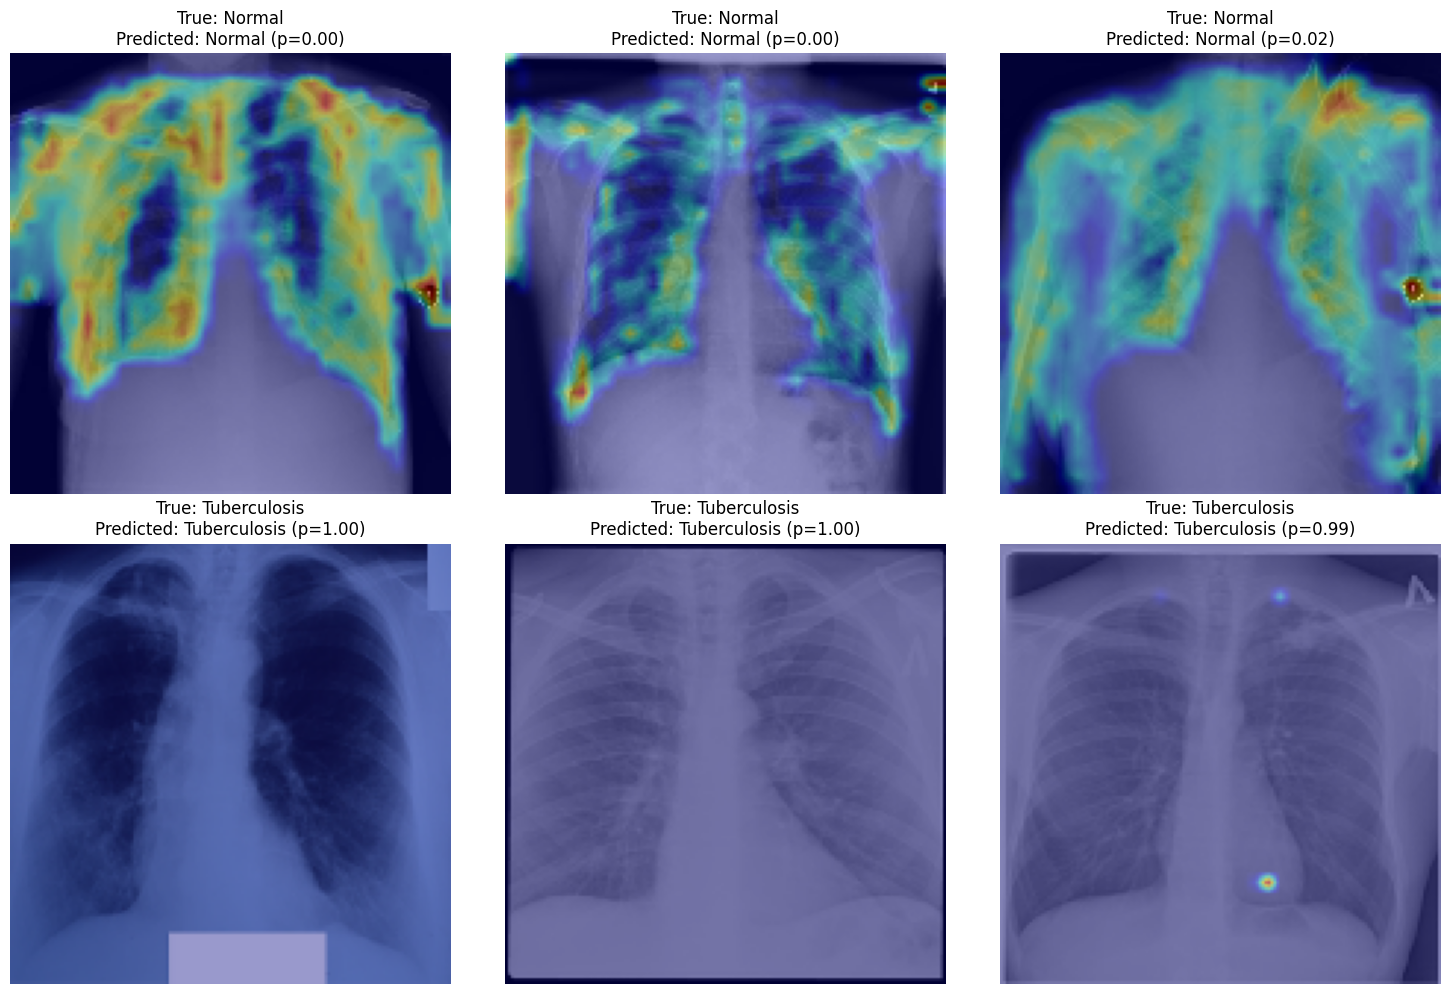

In [6]:
# ==============================================================================
#              MODEL EXPLAINABILITY WITH GRAD-CAM VISUALIZATIONS
# ==============================================================================

# --- 1. Library Imports and Configuration ---
import os
import random
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 2. Reproducibility Setup ---
# Fix random seeds to ensure consistent results across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- 3. Load Best Model and Validation Data ---
print("Loading the best trained model...")
model = load_model('../model/tb_cnn_model_best.keras')
print("Model loaded successfully.")

# Prepare a data generator to fetch validation images for visualization
DATA_DIR = os.path.join('..', 'data', 'TB_Chest_Radiography_Database')
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
validation_generator = validation_datagen.flow_from_directory(
    DATA_DIR,
    subset='validation',
    target_size=(150, 150),
    batch_size=1,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)

# Create a mapping from class index to class name
idx_to_class = {v: k for k, v in validation_generator.class_indices.items()}
print(f"Classes: {idx_to_class}")

# --- 4. Grad-CAM Helper Functions ---
def find_last_conv_layer(model):
    """
    Finds the name of the last convolutional layer in the model.
    """
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, y_pred_label):
    """
    Generates a Grad-CAM heatmap using manual graph reconstruction.
    This method works reliably with loaded Sequential models.
    """
    inputs = tf.keras.Input(shape=img_array.shape[1:])
    x = inputs
    conv_output = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x

    grad_model = tf.keras.Model(inputs, [conv_output, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if y_pred_label == 1:
           class_channel = predictions[:, 0]
        else:
           class_channel = 1 - predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8)
    return heatmap

def overlay_heatmap(heatmap, img_bgr, alpha=0.4):
    """
    Superimposes the Grad-CAM heatmap on the original image.
    """
    heatmap = cv2.resize(heatmap, (img_bgr.shape[1], img_bgr.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted(heatmap_color, alpha, img_bgr, 1 - alpha, 0)

# --- 5. Generate and Display Visualizations ---
print("\nGenerating Grad-CAM visualizations...")

last_conv_layer_name = find_last_conv_layer(model)

# Store 3 Normal and 3 Tuberculosis examples
normal_examples = []
tb_examples = []

validation_generator.reset()

while len(normal_examples) < 3 or len(tb_examples) < 3:

    img_batch, label_batch = next(validation_generator)

    for img, label in zip(img_batch, label_batch):

        label = int(label)

        if label == 0 and len(normal_examples) < 3:
            normal_examples.append((img, label))

        elif label == 1 and len(tb_examples) < 3:
            tb_examples.append((img, label))

        if len(normal_examples) == 3 and len(tb_examples) == 3:
            break


# Combine 3 Normal + 3 Tuberculosis
examples = normal_examples + tb_examples

plt.figure(figsize=(15, 10))

for i, (img, y_true_label) in enumerate(examples):

    # Add batch dimension
    img_tensor = np.expand_dims(img, axis=0)

    # Prediction
    pred_score = model.predict(
        img_tensor,
        verbose=0
    )[0][0]

    y_pred_label = 1 if pred_score >= 0.5 else 0

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_tensor,
        model,
        last_conv_layer_name,
        y_pred_label
    )

    # Prepare image
    img_bgr = cv2.cvtColor(
        (img * 255).astype(np.uint8),
        cv2.COLOR_RGB2BGR
    )

    # Overlay
    overlaid_img = overlay_heatmap(
        heatmap,
        img_bgr
    )

    # RGB for matplotlib
    img_to_show = cv2.cvtColor(
        overlaid_img,
        cv2.COLOR_BGR2RGB
    )

    # Class names
    true_class = idx_to_class[y_true_label]
    pred_class = idx_to_class[y_pred_label]

    # Display
    ax = plt.subplot(2, 3, i + 1)

    plt.title(
        f"True: {true_class}\n"
        f"Predicted: {pred_class} (p={pred_score:.2f})"
    )

    plt.imshow(img_to_show)
    plt.axis("off")


plt.tight_layout()
plt.savefig("gradcam_mixed_examples.png")
plt.show()